Computing recurrence intervals for IMERG time series at Hunt Texas

8/11/2026 JRS

In [ ]:
# Import packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyextremes import EVA


In [17]:
# Import time series data

df = pd.read_csv('./Data/hunt_texas_IMERG_daily.txt')
df.columns = ['date','precip_mm']
print(df.head())

ds_series = df.set_index('date')['precip_mm']
print(ds_series.head())

ds_series.index = pd.to_datetime(ds_series.index)


         date  precip_mm
0  1998-01-01      0.000
1  1998-01-02      0.000
2  1998-01-03      0.085
3  1998-01-04      0.000
4  1998-01-05      0.000
date
1998-01-01    0.000
1998-01-02    0.000
1998-01-03    0.085
1998-01-04    0.000
1998-01-05    0.000
Name: precip_mm, dtype: float64


In [18]:
# Clean data

# Remove zeros
df_noz = ds_series[ds_series>0]
print(df_noz.head())
print(len(df_noz))
print(len(ds_series))

# Remove trends, etc. if needed



date
1998-01-03     0.085
1998-01-06    27.195
1998-01-07     0.755
1998-01-20     0.260
1998-01-22     1.305
Name: precip_mm, dtype: float64
3221
10135


None
date
1998-10-06    107.755
1999-06-13     58.355
2000-10-23     68.595
2001-11-15     94.000
2002-07-04     98.555
2003-09-12     45.975
2004-06-29     68.760
2005-08-10     51.860
2006-10-10     58.815
2007-05-25     75.755
2008-08-12     35.130
2009-04-17     52.375
2010-02-03     51.460
2011-10-09     73.910
2012-03-20     74.845
2013-09-08     59.465
2014-05-26     56.795
2015-10-24     73.550
2016-05-29     80.110
2017-08-07     85.365
2018-09-04     77.245
2019-06-17     39.980
2020-05-16     51.390
2021-04-29     74.715
2022-08-22     33.800
2023-09-25     62.680
2024-07-23     99.590
2025-07-04    104.625
Name: precip_mm, dtype: float64


(<Figure size 768x480 with 1 Axes>, <Axes: xlabel='date', ylabel='precip_mm'>)

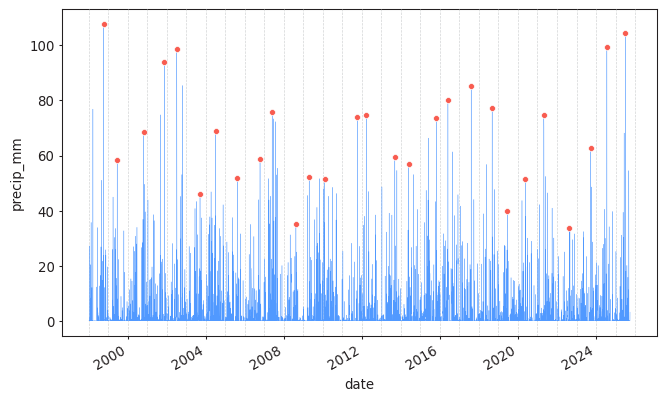

In [29]:
# Create model for the time series data

model = EVA(ds_series)
out = model.get_extremes(method = "BM", block_size="365.2425D")
print(out)
print(model.extremes)
model.plot_extremes()

                           Univariate Extreme Value Analysis                            
                                      Source Data                                       
----------------------------------------------------------------------------------------
Data label:                     precip_mm      Size:                              10,135
Start:                       January 1998      End:                       September 2025
                                     Extreme Values                                     
----------------------------------------------------------------------------------------
Count:                                 28      Extraction method:                     BM
Type:                                high      Block size:             365 days 05:49:12
                                         Model                                          
----------------------------------------------------------------------------------------
Model:               

(<Figure size 768x480 with 1 Axes>,
 <Axes: xlabel='Return period', ylabel='precip_mm'>)

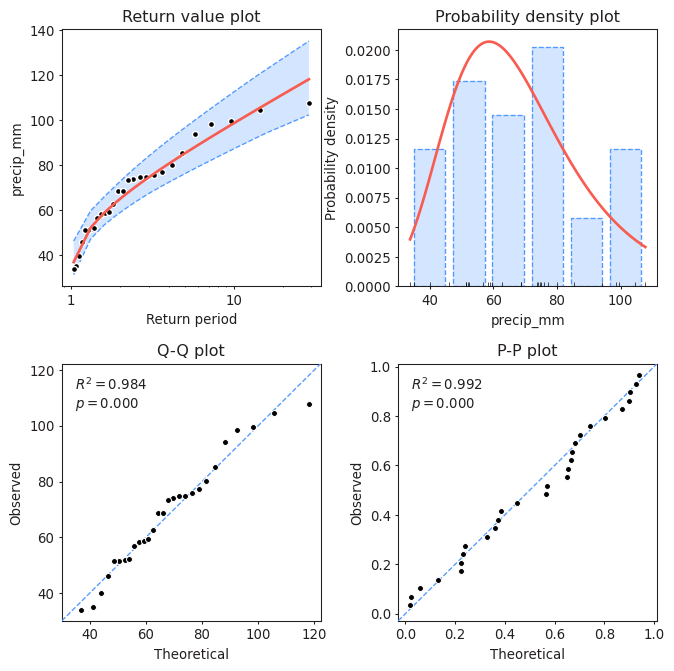

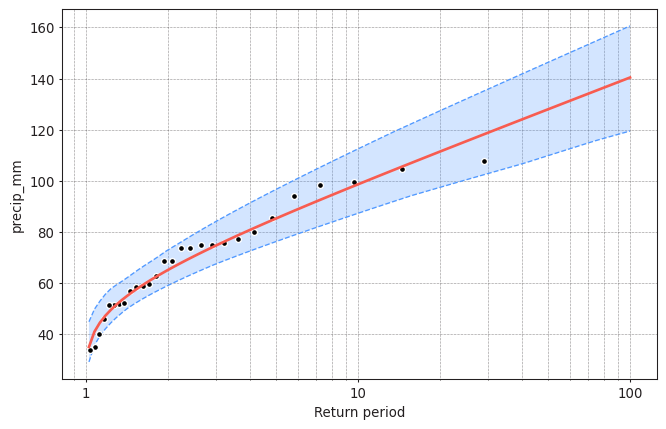

In [32]:
# Fit a model to the extreme values

model.fit_model() # default fitting method is MLE
print(model)

model.plot_diagnostic(alpha=0.95)

model.plot_return_values(
    return_period = np.logspace(0.01,2,100),
    return_period_size = "365.2425D",
    alpha = 0.95
)

In [35]:
# Estimate return values

summary = model.get_summary(
    return_period=[1, 2, 5, 10, 25, 50, 100],
    alpha=0.95,
    n_samples=1000,
)
print(summary)

               return value    lower ci    upper ci
return period                                      
1.0                    -inf         NaN         NaN
2.0               65.164572   58.558963   73.069143
5.0               85.310969   75.321969   95.314095
10.0              98.649637   85.837066  110.006094
25.0             115.503079   98.373536  129.976390
50.0             128.005925  107.935399  144.915288
100.0            140.416452  117.319323  159.583954


In [ ]:

# Plot histogram (with zeros)

df['precip_mm'].hist(bins = 50, edgecolor='black')
plt.title('Precipitation histogram')
plt.xlabel('Precip (mm/day)')
plt.ylabel('Count')

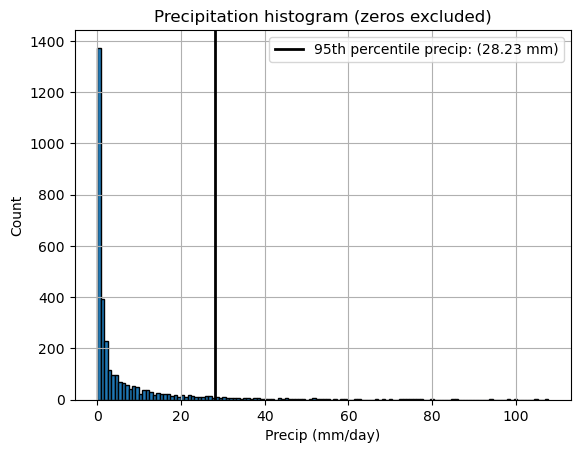

In [4]:
# Plot histogram (without zeros)

df_noz = df[df['precip_mm']>0]
p95 = np.percentile(df_noz['precip_mm'], 95) # calculate 95% precipitation

df_noz['precip_mm'].hist(bins = "fd", edgecolor='black')
plt.axvline(x = p95, 
    color = "black", 
    linewidth = 2, 
    label=f"95th percentile precip: ({p95:.2f} mm)"
)

plt.title('Precipitation histogram (zeros excluded)')
plt.xlabel('Precip (mm/day)')
plt.ylabel('Count')
plt.legend()



In [5]:
# Implement annual maximum method



161


Text(0, 0.5, 'Count')

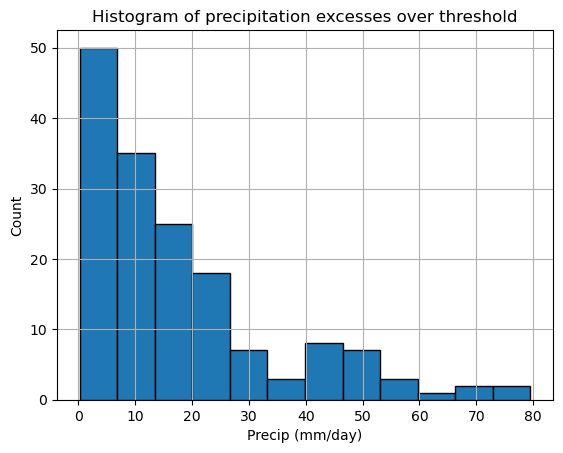

In [6]:
# Implement peak-over-threshold (POT) method

# Choosing threshold of p95 for peak-over-threshold method
threshold = p95 # this might be too low...

# Get precipitation data over the threshold value
df_peaks = df_noz[df_noz['precip_mm']>threshold]
df_peaks.head()
print(len(df_peaks))

df_excesses = df_peaks['precip_mm'] - threshold

# Plot histogram of extreme values
df_excesses.hist(bins = "fd", edgecolor = "black")
plt.title('Histogram of precipitation excesses over threshold')
plt.xlabel('Precip (mm/day)')
plt.ylabel('Count')

# We should implement a check to remove consecutive peaks that are actually part of the same storm event
# For example, ensure there is at least one full day in between peaks
# This will help with independence, and satisfying the extreme value theorem, which requires i.i.d. random variables


In [7]:
# Select a threshold

